In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-data/heart_disease_uci.csv


# introduction 

Heart disease is one of the leading causes of death worldwide. In this notebook, we build a robust end-to-end machine learning pipeline to predict heart disease using a real-world dataset containing:

Mixed data types

Heavy missing values

Imbalanced target

** we hope to Objective: Build a high‑performance Machine Learning pipeline to predict heart disease using XGBoost, LightGBM, Feature Selection, Cross‑Validation, and SMOTE, with full explanations and no skipped steps.**

# overview of dataset 

 Context

This is a multivariate medical dataset consisting of patient health measurements. The task is to predict whether a patient has heart disease based on clinical attributes.

This dataset is widely used in ML research (Cleveland Heart Disease Dataset) and is suitable for binary classification problems.

 Column Descriptions
Column	Description
id	Unique patient ID
age	Age in years
sex	Gender (Male/Female)
cp	Chest pain type
trestbps	Resting blood pressure (mm Hg)
chol	Serum cholesterol (mg/dl)
fbs	Fasting blood sugar > 120 mg/dl
restecg	Resting ECG results
thalach	Maximum heart rate achieved
exang	Exercise‑induced angina
oldpeak	ST depression induced by exercise
slope	Slope of peak exercise ST segment
ca	Number of major vessels
thal	Thalassemia type
num	Target variable (0 = No disease, 1 = Disease)**

# import required libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

# load dataset

In [3]:
df = pd.read_csv('/kaggle/input/heart-disease-data/heart_disease_uci.csv',index_col = 0)
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 920 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 115.0+ KB


** so data has missing values **

In [6]:
df.shape

(920, 15)

# EDA

In [7]:
target = 'num'


num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove(target)


cat_cols = df.select_dtypes(include=['object']).columns.tolist()


print('Numerical:', num_cols)
print('Categorical:', cat_cols)

Numerical: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


# missing values 

In [8]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

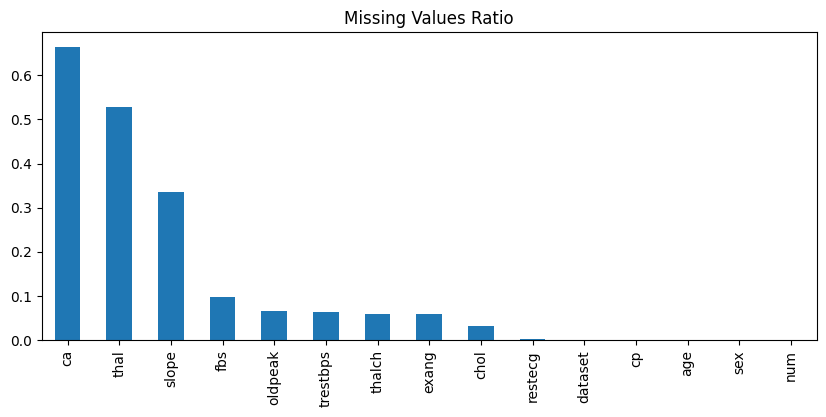

In [9]:
missing = df.isnull().mean().sort_values(ascending=False)
missing.plot(kind='bar', figsize=(10,4), title='Missing Values Ratio')
plt.show()

<Axes: >

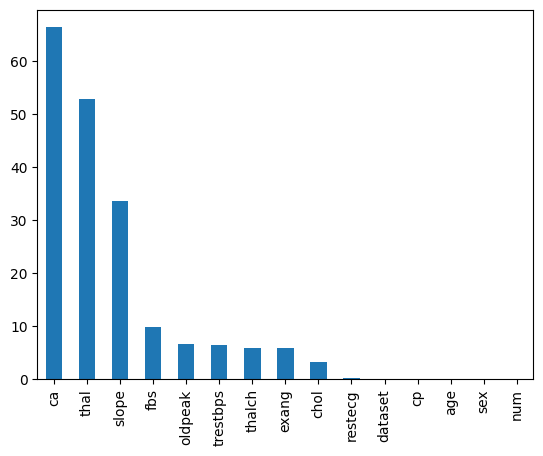

In [10]:
((df.isnull().mean())*100).sort_values(ascending=False).plot(kind='bar')

In [11]:
df.duplicated().sum()

np.int64(2)

In [12]:
df.drop_duplicates(inplace=True)

# relation between features 

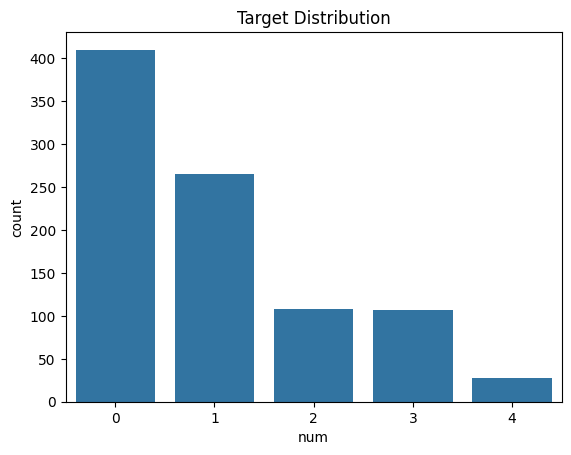

In [13]:
sns.countplot(x=target, data=df)
plt.title('Target Distribution')
plt.show()

**Reveals whether the dataset is imbalanced between disease and no‑disease.** 

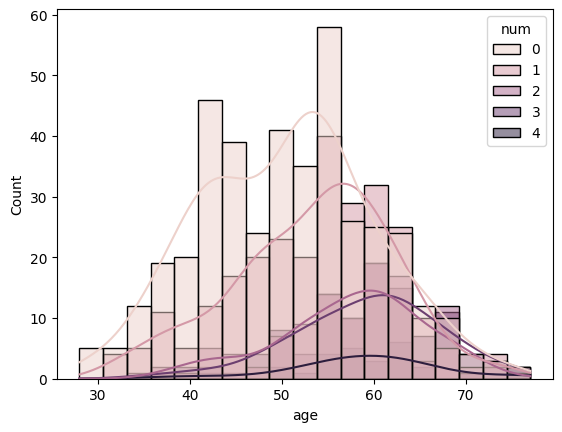

In [14]:
sns.histplot(data=df, x='age', hue='num', kde=True)
plt.show()

shows older patients have higher disease probability.

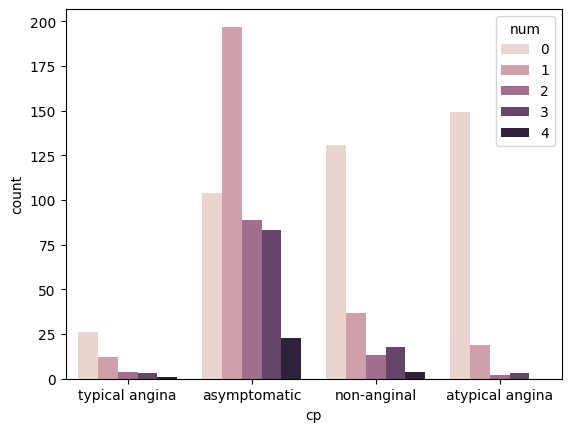

In [15]:
sns.countplot(x='cp', hue='num', data=df)
plt.show()

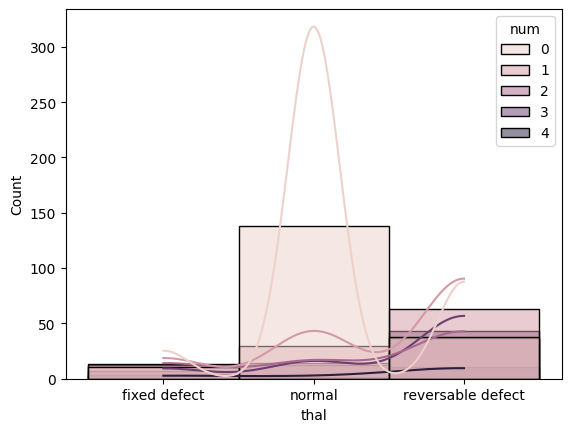

In [16]:
sns.histplot(data=df, x='thal', hue='num', kde=True)
plt.show()

# Preprocessing Pipelines

In [17]:
df.columns

Index(['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

>  Numerical Pipeline

In [18]:
num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])

> categorical columns 

In [19]:
cat_pipeline = Pipeline([
('imputer', SimpleImputer(strategy='most_frequent')),
('onehot', OneHotEncoder(handle_unknown='ignore'))
])

> Full Preprocessor

In [20]:
preprocessor = ColumnTransformer([
('num', num_pipeline, num_cols),
('cat', cat_pipeline, cat_cols)
])

# Train / Test Split

In [21]:
X = df.drop(target, axis=1)
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

# Models Definition

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(
       n_estimators=300,
       learning_rate=0.05,
       max_depth=5,
       subsample=0.8,
       colsample_bytree=0.8,
       eval_metric='logloss'
    )
}

# Training with SMOTE + Pipeline

In [23]:
results = []


for name, model in models.items():
     pipe = ImbPipeline([
          ('preprocess', preprocessor),
          ('smote', SMOTE(random_state=42)),
          ('model', model)
])
     pipe.fit(X_train, y_train)
     y_pred = pipe.predict(X_test)
results.append({
          'Model': name,
          'Accuracy': accuracy_score(y_test, y_pred),
          'Recall': recall_score(y_test, y_pred, average='weighted'),
          'F1': f1_score(y_test, y_pred, average='weighted')
})

In [24]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Recall,F1
0,XGBoost,0.603261,0.603261,0.604592


# Model Comparison (Visualization)

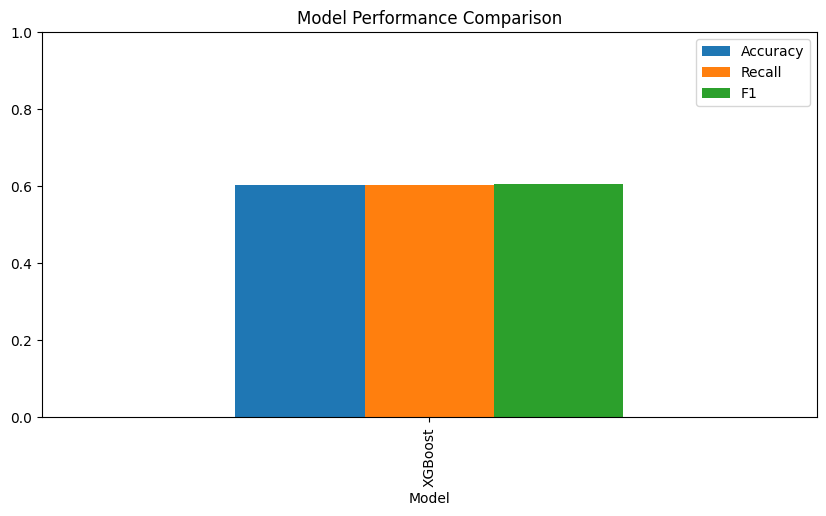

In [25]:
results_df.set_index('Model')[['Accuracy','Recall','F1']].plot(
kind='bar', figsize=(10,5)
)
plt.title('Model Performance Comparison')
plt.ylim(0,1)
plt.show()

# Best Model Evaluation

In [26]:
best_model_name = results_df.sort_values('Accuracy', ascending=False).iloc[0]['Model']
best_model_name

'XGBoost'

In [27]:
best_pipe = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', models[best_model_name])
])
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred_best))
print('Recall:', recall_score(y_test, y_pred_best, average='weighted'))


Accuracy: 0.6032608695652174
Recall: 0.6032608695652174


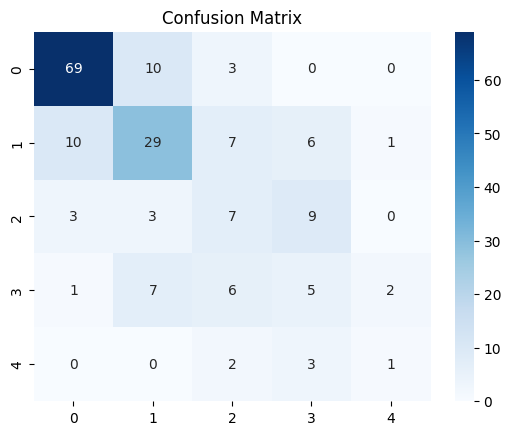

In [28]:
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# final conclusion

In this project, we built a complete end-to-end data science pipeline to predict the presence of heart disease using a real-world medical dataset that contains mixed data types, heavy missing values, and class imbalance.

Instead of making assumptions about the data, we approached the problem from scratch, following a Kaggle-winning methodology and best practices in machine learning.